### This notebook is for a personal project for machine learning and uses a diabetes risk prediction dataset from Kaggle.

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    precision_recall_curve
)

diabetesDF = pd.read_csv(r"C:\Users\santi\Code\diabetes_risk_prediction_dataset.csv")

print(diabetesDF.head())
diabetesDF.info()
diabetesDF.describe()


   Patient_ID   Age Gender        Country  Height_cm  Weight_kg   BMI  \
0           1  32.0   Male         Mexico      182.1       65.8  19.8   
1           2  42.0  Other   Saudi Arabia      148.5      101.2  45.9   
2           3  89.0  Other      Argentina      158.1        NaN  37.9   
3           4  87.0  Other  United States      190.9       95.9  26.3   
4           5  27.0  Other      Australia      156.9      101.9  41.4   

   Waist_Circumference_cm  Blood_Glucose  HbA1c  ...  Fatty_Liver  PCOS  \
0                    71.2           88.4   10.4  ...          Yes    No   
1                   121.8          247.3   11.3  ...          Yes   Yes   
2                   131.8          141.9    6.3  ...          Yes    No   
3                    99.1           90.1    7.4  ...           No    No   
4                    77.1           93.8   12.0  ...          Yes   Yes   

   Medication_Adherence   Work_Type  Residence_Type  Daily_Water_Intake_L  \
0                  Good     Retir

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.000000,49503.000000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,50000.000000,50000.000000,...,49000.000000,49000.000000,49000.000000,49000.000000,50000.000000,48008.000000,48036.000000,47983.000000,50000.000000,50000.000000
mean,25000.500000,53.871099,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,142.607294,23.476724,...,220.168635,57.371731,135.014524,229.543259,85.124260,5.017460,89.933442,6.500917,2.998842,74.043920
std,14433.901067,21.130148,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,44.681799,12.403841,...,57.793626,18.720696,49.135613,98.234911,20.390334,2.875922,52.034642,2.027793,1.152273,15.598327
min,1.000000,18.000000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,...,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.000000,3.000000,1.000000,13.000000
25%,12500.750000,35.000000,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,103.900000,12.800000,...,169.800000,41.300000,92.500000,144.700000,68.000000,2.500000,44.900000,4.700000,2.000000,64.000000
50%,25000.500000,54.000000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,...,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.800000,6.500000,3.000000,75.000000
75%,37500.250000,72.000000,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,181.500000,34.300000,...,270.500000,73.600000,177.700000,314.600000,103.000000,7.500000,135.200000,8.300000,4.000000,86.000000
max,50000.000000,90.000000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,...,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.000000,10.000000,5.000000,100.000000


In [86]:
import sklearn
from sklearn.ensemble import RandomForestRegressor as r
from sklearn.metrics import mean_squared_error, r2_score

diabetesDF = diabetesDF.select_dtypes(include=['float64', 'int64'])  # Select only numeric columns
diabetesDF = diabetesDF.dropna()  # Drop rows with missing values
diabetesDF = diabetesDF.drop(columns=['Patient_ID'])  # Drop the Patient_ID column as it is not a feature

# target col
target = 'Diabetes_Risk_Score'

X = diabetesDF.drop(columns=target)
y = diabetesDF[target]


scaler = StandardScaler() # This is to standardize the features by removing the mean and scaling to unit variance
X_train, X_test, y_train, y_test = train_test_split(
    X, # This is to select all columns except the target one as features
    y, # This is to select the target column
    test_size=0.2,
    random_state=42
) # This is for splitting the dataset into training and testing sets, with 20% of the data reserved for testing and a random state for reproducibility


X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

## Convert back to DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test.columns)

regressor = r() # The chosen model
regressor.fit(X_train_scaled_array, y_train) # Fit the model to the training data

regressor.predict(X_test_scaled_array) # Make predictions on the test data

from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report

y_pred = regressor.predict(X_test_scaled_array) # Make predictions on the test data
print(r2_score(y_test, y_pred))



0.6503033421538231


In [95]:
import pandas as pd
 

importances = pd.Series(regressor.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top Feature Importances:\n", importances) # check which params are important to score

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor

param_grid = {
    'max_iter': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 8]
}

grid_search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='r2'
)
grid_search.fit(X_train_scaled_array, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned Ensemble R² Score: {grid_search.best_score_:.4f}")

Top Feature Importances:
 Fasting_Blood_Sugar         0.294127
HbA1c                       0.193735
Age                         0.097496
BMI                         0.077905
Blood_Pressure_Systolic     0.048717
Total_Cholesterol           0.037129
Blood_Pressure_Diastolic    0.029211
Sleep_Hours                 0.022210
Daily_Walking_Minutes       0.017864
Triglycerides               0.017643
LDL                         0.017422
Waist_Circumference_cm      0.017192
HDL                         0.017050
Insulin_Level               0.016946
Weight_kg                   0.016842
Blood_Glucose               0.016840
Exercise_Hours_Per_Week     0.016336
Height_cm                   0.015859
Heart_Rate                  0.015431
Daily_Water_Intake_L        0.014045
dtype: float64
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 100}
Tuned Ensemble R² Score: 0.6705


C:\Users\santi\AppData\Local\Temp\ipykernel_7360\3229252495.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


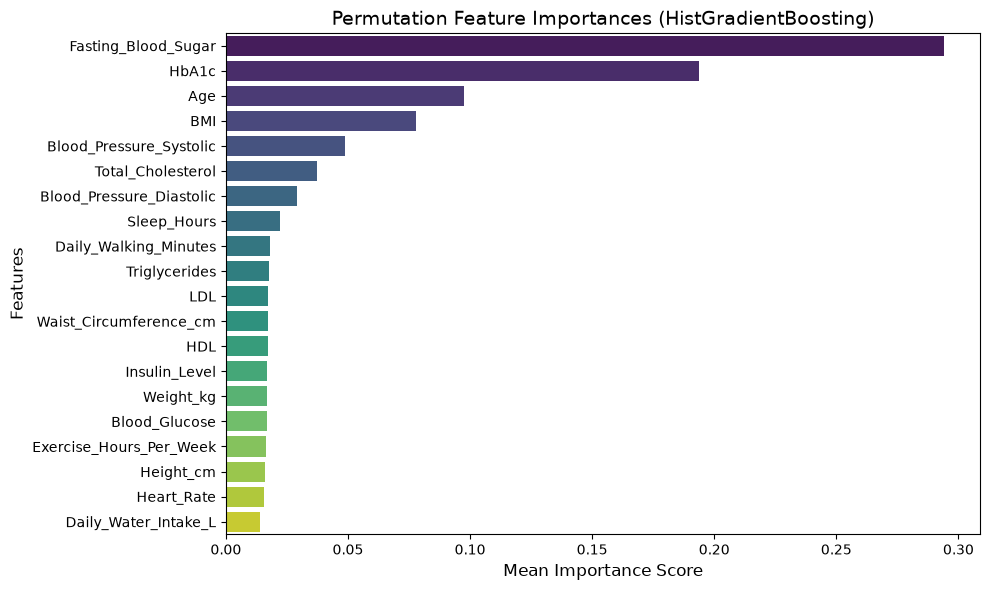

In [88]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Permutation Feature Importances (HistGradientBoosting)', fontsize=14)
plt.xlabel('Mean Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [96]:
import pandas as pd

# 1. Define your new patient data dictionary
new_patient_data = {
    'Fasting_Blood_Sugar': [115.0],
    'HbA1c': [6.2],
    'Age': [45],
    'BMI': [28.4],
    'Blood_Pressure_Systolic': [130],
    'Total_Cholesterol': [210],
    'Blood_Pressure_Diastolic': [85],
    'Sleep_Hours': [6.5],
    'Daily_Walking_Minutes': [30],
    'Triglycerides': [150],
    'LDL': [130],
    'HDL': [45],
    'Insulin_Level': [15],
    'Blood_Glucose': [120],
    'Waist_Circumference_cm': [92],
    'Weight_kg': [82],
    'Exercise_Hours_Per_Week': [2.5],
    'Height_cm': [175],
    'Heart_Rate': [72],
    'Daily_Water_Intake_L': [2.0]
}

# 2. Create DataFrame
new_patient_df = pd.DataFrame(new_patient_data)

# 3. FORCE column order to match X_train exactly
new_patient_df = new_patient_df[X_train.columns]

# 4. Scale and predict safely
new_patient_scaled = scaler.transform(new_patient_df)
predicted_score = grid_search.best_estimator_.predict(new_patient_scaled)[0]

print(f"Predicted Diabetes Risk Score: {predicted_score:.2f}")

Predicted Diabetes Risk Score: 54.94


In [97]:
import pandas as pd

# Mock Patient 1: Low Diabetes Risk Profile
# Features low/normal fasting blood sugar, HbA1c, BMI, and younger age
low_risk_patient = {
    'Fasting_Blood_Sugar': 85.0,        # Normal range (<100 mg/dL)
    'HbA1c': 5.2,                       # Normal range (<5.7%)
    'Age': 28,                          # Lower risk demographic
    'BMI': 21.5,                        # Normal weight range
    'Blood_Pressure_Systolic': 115,      # Optimal BP
    'Total_Cholesterol': 170,           # Desirable range
    'Blood_Pressure_Diastolic': 75,
    'Sleep_Hours': 7.5,
    'Daily_Walking_Minutes': 45,
    'Triglycerides': 90,
    'Waist_Circumference_cm': 78,
    'LDL': 100,
    'HDL': 60,
    'Insulin_Level': 8,
    'Blood_Glucose': 90,
    'Weight_kg': 62,
    'Exercise_Hours_Per_Week': 4.0,
    'Height_cm': 170,
    'Heart_Rate': 68,
    'Daily_Water_Intake_L': 2.5
}

# Mock Patient 2: High Diabetes Risk Profile
# Features elevated fasting blood sugar, HbA1c in diabetic range, higher BMI, and older age
high_risk_patient = {
    'Fasting_Blood_Sugar': 165.0,       # Elevated (Diabetic threshold >= 126 mg/dL)
    'HbA1c': 8.5,                       # Elevated (Diabetic threshold >= 6.5%)
    'Age': 62,                          # Higher risk demographic
    'BMI': 34.2,                        # Class I Obesity range
    'Blood_Pressure_Systolic': 148,      # Stage 2 Hypertension
    'Total_Cholesterol': 245,           # High cholesterol
    'Blood_Pressure_Diastolic': 92,
    'Sleep_Hours': 5.0,
    'Daily_Walking_Minutes': 10,
    'Triglycerides': 220,
    'Waist_Circumference_cm': 108,
    'LDL': 160,
    'HDL': 35,
    'Insulin_Level': 28,
    'Blood_Glucose': 175,
    'Weight_kg': 102,
    'Exercise_Hours_Per_Week': 0.5,
    'Height_cm': 172,
    'Heart_Rate': 82,
    'Daily_Water_Intake_L': 1.0
}

lowDF = pd.DataFrame([low_risk_patient])
highDF = pd.DataFrame([high_risk_patient])

lowDF = lowDF[X_train.columns] # Force column order to match X_train exactly
highDF = highDF[X_train.columns] # Force column order to match X_train exactly

lowScaled = scaler.transform(lowDF)
highScaled = scaler.transform(highDF)

low_predicted_score = grid_search.best_estimator_.predict(lowScaled)[0]
high_predicted_score = grid_search.best_estimator_.predict(highScaled)[0]

print(f"Predicted Diabetes Risk Score for Low-Risk Patient: {low_predicted_score:.2f}")
print(f"Predicted Diabetes Risk Score for High-Risk Patient: {high_predicted_score:.2f}")


Predicted Diabetes Risk Score for Low-Risk Patient: 27.76
Predicted Diabetes Risk Score for High-Risk Patient: 97.24


In [100]:
# Converting continuous risk scores into categorical risk levels
def categorize_risk(score):
    if score < 33:
        return "Low Risk"
    elif 33 <= score < 66:
        return "Moderate Risk"
    else:
        return "High Risk"

categorized_low_risk = categorize_risk(low_predicted_score)
categorized_high_risk = categorize_risk(high_predicted_score)

print(f"Categorized Risk Level for Low-Risk Patient: {categorized_low_risk} with score of {low_predicted_score:.2f}")
print(f"Categorized Risk Level for High-Risk Patient: {categorized_high_risk} with score of {high_predicted_score:.2f}")

Categorized Risk Level for Low-Risk Patient: Low Risk with score of 27.76
Categorized Risk Level for High-Risk Patient: High Risk with score of 97.24


In [103]:
import joblib

# Export model and scaler artifacts
joblib.dump(regressor, 'diabetes_random_forest.pkl', compress=3)
joblib.dump(scaler, 'diabetes_scaler.pkl')

print("Pipeline saved successfully!")

Pipeline saved successfully!
